<a href="https://colab.research.google.com/github/filfish2007-cav/Hospital_LLM/blob/main/DataCleaning_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/filfish2007-cav/Hospital_LLM/blob/main/notebooks/Hospital_Data_Cleaning_EDA_Optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital data cleaning & exploratory analysis

**Goal:** prepare six linked Synthea hospital tables for a portfolio hospital-AI project. The notebook keeps the useful checks from the original analysis, but presents them as a short, reproducible workflow rather than a long investigation log.

**Cleaning approach:** correct safe formatting/privacy issues, remove confirmed exact duplicates, standardize a few known unit/description variants, and *flag rather than delete* clinically unusual values. The final section exports clean, database-ready CSVs and a transparent quality report.


## 1. Setup and load data

The default source is the project repository, so this runs directly in Google Colab. Change `BASE_URL` if the raw CSV folder is stored elsewhere. Run all cells from top to bottom.


In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_PLOTTING = True
except ImportError:  # lets non-Colab validation run without plotting packages
    HAS_PLOTTING = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BASE_URL = "https://raw.githubusercontent.com/filfish2007-cav/Hospital_LLM/main/data/hospital_csvs/"
OUTPUT_DIR = Path("cleaned")
REFERENCE_DATE = pd.Timestamp("2026-09-30")  # dataset reference point, not today's date

TABLES = ["patients", "encounters", "conditions", "medications", "observations", "procedures"]
files = {name: f"{name}.csv" for name in TABLES}

# Keep ZIP/FIPS as text so leading zeroes survive the round trip.
data = {
    name: pd.read_csv(
        BASE_URL + filename,
        dtype={"ZIP": "string", "FIPS": "string"} if name == "patients" else None,
    )
    for name, filename in files.items()
}
raw_rows = {name: len(df) for name, df in data.items()}

def show(frame, n=10):
    # Compact display that also works outside a notebook.
    try:
        display(frame.head(n))
    except NameError:
        print(frame.head(n).to_string())

def snake_case(name):
    name = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", name)
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", name)
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

for name, frame in data.items():
    frame.columns = [snake_case(column) for column in frame.columns]

overview = pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": len(df.columns), "exact_duplicates": int(df.duplicated().sum())}
    for name, df in data.items()
])
show(overview, len(overview))


,table,rows,columns,exact_duplicates
0,patients,120,28,0
1,encounters,7042,15,0
2,conditions,5099,7,0
3,medications,8001,13,0
4,observations,117524,9,22
5,procedures,21901,10,0


## 2. Reusable validation helpers

These helpers replace repeated one-off checks while keeping the same substantive audit: keys, foreign keys, patient/encounter agreement, date order, code mappings, paired fields, and numeric sanity checks.


In [2]:
def utc_naive(series):
    return pd.to_datetime(series, errors="coerce", utc=True).dt.tz_localize(None)

def clean_key(series):
    return series.astype("string").str.strip()

def fk_audit(child, child_col, parent, parent_col="id"):
    values = child[child_col]
    present = values.notna()
    orphan = present & ~values.isin(parent[parent_col])
    return {"null": int((~present).sum()), "orphan": int(orphan.sum())}

def patient_encounter_audit(child, encounters):
    # Check that a child row's patient agrees with its referenced encounter.
    rows = child[child["encounter"].notna()].merge(
        encounters[["id", "patient"]], left_on="encounter", right_on="id", how="left", suffixes=("", "_enc")
    )
    missing_encounter = rows["id"].isna()
    mismatch = ~missing_encounter & (rows["patient"] != rows["patient_enc"])
    return {"missing_encounter": int(missing_encounter.sum()), "patient_mismatch": int(mismatch.sum())}

def code_mapping_audit(frame, code="code", description="description"):
    pairs = frame[[code, description]].dropna().drop_duplicates()
    return {
        "codes": int(pairs[code].nunique()),
        "descriptions": int(pairs[description].nunique()),
        "codes_with_multiple_descriptions": int((pairs.groupby(code)[description].nunique() > 1).sum()),
    }

def paired_missing_audit(frame, left, right):
    left_null, right_null = frame[left].isna(), frame[right].isna()
    return {"both_missing": int((left_null & right_null).sum()), "partial_missing": int((left_null ^ right_null).sum())}

def lifetime_audit(frame, event_date, patients, description_col="description", tolerance_days=1):
    # Return events outside a patient's lifetime; expected death records are separated.
    joined = frame[["patient", event_date, description_col]].merge(
        patients[["id", "birthdate", "deathdate"]], left_on="patient", right_on="id", how="left"
    )
    before = joined[event_date] < joined["birthdate"] - pd.Timedelta(days=tolerance_days)
    after = joined["deathdate"].notna() & (joined[event_date] > joined["deathdate"] + pd.Timedelta(days=tolerance_days))
    death_admin = joined[description_col].fillna("").str.contains(
        r"death certification|cause of death|qaly|daly|qols", case=False, regex=True
    )
    return {"before_birth": int(before.sum()), "after_death_expected": int((after & death_admin).sum()), "after_death_unexpected": int((after & ~death_admin).sum())}

def add_change(table, action, rows):
    change_log.append({"table": table, "action": action, "rows_affected": int(rows)})

change_log = []


## 3. Safe standardization and confirmed duplicate removal

IDs and relationship keys are trimmed without changing their values. The original notebook identified 22 redundant exact observation rows; they have no observation ID or downstream references, so keeping one copy is safe. Address observations are excluded because they are not needed by the AI project and expose unnecessary location data.


In [3]:
for table, columns in {
    "patients": ["id"],
    "encounters": ["id", "patient"],
    "conditions": ["patient", "encounter"],
    "medications": ["patient", "encounter"],
    "observations": ["patient", "encounter"],
    "procedures": ["patient", "encounter"],
}.items():
    for column in columns:
        if column in data[table]:
            data[table][column] = clean_key(data[table][column])

observations = data["observations"]
duplicate_observations = int(observations.duplicated().sum())
data["observations"] = observations.drop_duplicates().copy()
add_change("observations", "removed confirmed exact duplicate rows", duplicate_observations)

address_rows = data["observations"]["description"].eq("Address")
data["observations"] = data["observations"].loc[~address_rows].copy()
add_change("observations", "removed address observations (unneeded location PII)", address_rows.sum())

print(pd.DataFrame(change_log).to_string(index=False))


       table                                               action  rows_affected
observations               removed confirmed exact duplicate rows             22
observations removed address observations (unneeded location PII)           1525


## 4. Patients: dates, geography, financial sanity, and privacy

Missing death dates and optional demographic fields are retained as nulls. The cleaning only fixes reliable geographic issues: placeholder/out-of-state ZIPs and county-derived FIPS values. It then removes the unnecessary identifying fields already identified in the original analysis.


In [4]:
patients = data["patients"].copy()
patients["birthdate"] = pd.to_datetime(patients["birthdate"], errors="coerce")
patients["deathdate"] = pd.to_datetime(patients["deathdate"], errors="coerce")

# Preserve leading zeros and correct the one county-level FIPS mismatch found in the source data.
patients["zip"] = patients["zip"].astype("string").str.strip().str.zfill(5)
invalid_zip = patients["zip"].isin(["00000", "02861"])
patients.loc[invalid_zip, "zip"] = pd.NA
add_change("patients", "set placeholder/out-of-scope ZIPs to null", invalid_zip.sum())

county_fips = {
    "Barnstable": "25001", "Berkshire": "25003", "Bristol": "25005", "Dukes": "25007",
    "Essex": "25009", "Franklin": "25011", "Hampden": "25013", "Hampshire": "25015",
    "Middlesex": "25017", "Nantucket": "25019", "Norfolk": "25021", "Plymouth": "25023",
    "Suffolk": "25025", "Worcester": "25027",
}
expected_fips = patients["county"].astype("string").str.replace(" County", "", regex=False).map(county_fips)
fips_changed = expected_fips.notna() & (patients["fips"].astype("string") != expected_fips)
patients.loc[expected_fips.notna(), "fips"] = expected_fips[expected_fips.notna()]
patients["fips"] = patients["fips"].astype("string")
add_change("patients", "filled/corrected county-derived FIPS", fips_changed.sum())

patients["lat"] = pd.to_numeric(patients["lat"], errors="coerce").round(2)
patients["lon"] = pd.to_numeric(patients["lon"], errors="coerce").round(2)

patient_checks = {
    "null_id": int(patients["id"].isna().sum()),
    "duplicate_id": int(patients["id"].duplicated().sum()),
    "death_before_birth": int((patients["deathdate"] < patients["birthdate"]).sum()),
    "future_birthdate": int((patients["birthdate"] > REFERENCE_DATE).sum()),
    "invalid_coordinates": int((~patients["lat"].between(-90, 90) | ~patients["lon"].between(-180, 180)).sum()),
    "negative_financial_values": int((patients[["healthcare_expenses", "healthcare_coverage", "income"]] < 0).any(axis=1).sum()),
}
print("Patient checks:", patient_checks)

pii_columns = ["ssn", "drivers", "passport", "address", "maiden", "birthplace", "prefix", "suffix", "middle"]
patients = patients.drop(columns=pii_columns, errors="ignore")
add_change("patients", "dropped unnecessary direct-identifying columns", len([c for c in pii_columns if c in data["patients"].columns]))
data["patients"] = patients


Patient checks: {'null_id': 0, 'duplicate_id': 0, 'death_before_birth': 0, 'future_birthdate': 0, 'invalid_coordinates': 0, 'negative_financial_values': 0}


## 5. Encounters: keys, timeline, classes, costs, and reasons

Long stays are retained because SNF, hospice, and inpatient visits can legitimately last days. Death certification records are explicitly recognized so they do not get mistaken for bad clinical timeline data.


In [5]:
enc = data["encounters"].copy()
enc["start_dt"], enc["stop_dt"] = utc_naive(enc["start"]), utc_naive(enc["stop"])
enc["duration_hours"] = (enc["stop_dt"] - enc["start_dt"]).dt.total_seconds() / 3600
enc["is_death_certification"] = enc["description"].fillna("").str.contains("Death Certification", case=False)
enc["reasoncode"] = enc["reasoncode"].astype("string").str.replace(r"\.0$", "", regex=True)

expected_classes = {"wellness", "ambulatory", "urgentcare", "inpatient", "outpatient", "emergency", "snf", "hospice", "virtual", "home"}
encounter_checks = {
    "null_id": int(enc["id"].isna().sum()),
    "duplicate_id": int(enc["id"].duplicated().sum()),
    **fk_audit(enc, "patient", data["patients"]),
    "unparsed_dates": int(enc[["start_dt", "stop_dt"]].isna().any(axis=1).sum()),
    "non_positive_duration": int((enc["duration_hours"] <= 0).sum()),
    "unexpected_class": int((~enc["encounterclass"].isin(expected_classes)).sum()),
    "negative_cost": int((enc[["base_encounter_cost", "total_claim_cost", "payer_coverage"]] < 0).any(axis=1).sum()),
    "coverage_over_claim": int((enc["payer_coverage"] > enc["total_claim_cost"] + 0.01).sum()),
    "claim_below_base": int((enc["total_claim_cost"] + 0.01 < enc["base_encounter_cost"]).sum()),
    **{f"reason_{k}": v for k, v in paired_missing_audit(enc, "reasoncode", "reasondescription").items()},
    **{f"timeline_{k}": v for k, v in lifetime_audit(enc, "start_dt", data["patients"]).items()},
}
print(pd.Series(encounter_checks).to_string())
data["encounters"] = enc


null_id                               0
duplicate_id                          0
null                                  0
orphan                                0
unparsed_dates                        0
non_positive_duration                 0
unexpected_class                      0
negative_cost                         0
coverage_over_claim                   0
claim_below_base                      0
reason_both_missing                3209
reason_partial_missing                0
timeline_before_birth                 0
timeline_after_death_expected        18
timeline_after_death_unexpected       0


## 6. Conditions: relationships, dates, codes, and repeated events

Open conditions stay open when `stop` is missing. A condition that starts after its linked encounter is flagged for review, not removed: chronic diagnoses may be recorded after the visit that established the relationship.


In [6]:
con = data["conditions"].copy()
con["start_dt"], con["stop_dt"] = pd.to_datetime(con["start"], errors="coerce"), pd.to_datetime(con["stop"], errors="coerce")
con["code"] = con["code"].astype("string").str.replace(r"\.0$", "", regex=True)
con_enc = con.merge(enc[["id", "patient", "start_dt", "stop_dt"]], left_on="encounter", right_on="id", how="left", suffixes=("", "_enc"))
condition_checks = {
    **{f"patient_{k}": v for k, v in fk_audit(con, "patient", data["patients"]).items()},
    **{f"encounter_{k}": v for k, v in fk_audit(con, "encounter", enc).items()},
    **patient_encounter_audit(con, enc),
    "unparsed_dates": int(con[["start_dt", "stop_dt"]].isna().any(axis=1).sum() - con["stop_dt"].isna().sum()),
    "stop_before_start": int((con["stop_dt"] < con["start_dt"]).sum()),
    "starts_after_encounter": int((con_enc["start_dt"] > con_enc["stop_dt_enc"]).sum()),
    "event_duplicates": int(con.duplicated(["patient", "encounter", "code", "start"]).sum()),
    **{f"timeline_{k}": v for k, v in lifetime_audit(con, "start_dt", data["patients"]).items()},
    **{f"code_{k}": v for k, v in code_mapping_audit(con).items()},
}
print(pd.Series(condition_checks).to_string())
data["conditions"] = con


patient_null                                0
patient_orphan                              0
encounter_null                              0
encounter_orphan                            0
missing_encounter                           0
patient_mismatch                            0
unparsed_dates                              0
stop_before_start                           0
starts_after_encounter                   1309
event_duplicates                            0
timeline_before_birth                       0
timeline_after_death_expected               0
timeline_after_death_unexpected             0
code_codes                                185
code_descriptions                         185
code_codes_with_multiple_descriptions       0


## 7. Medications: dates, relationships, costs, descriptions, and reasons

This retains the original notebook's cost equation check and capitalization normalization. The small set of zero-duration duplicate-like events is flagged for review rather than deleted automatically.


In [7]:
med = data["medications"].copy()
med["start_dt"], med["stop_dt"] = utc_naive(med["start"]), utc_naive(med["stop"])
med["code"] = med["code"].astype("string").str.replace(r"\.0$", "", regex=True)
med["reasoncode"] = med["reasoncode"].astype("string").str.replace(r"\.0$", "", regex=True)
med["description"] = med["description"].astype("string").str.replace(r"\s+", " ", regex=True).str.strip()
canonical_description = med.groupby("code")["description"].agg(lambda s: s.value_counts().index[0])
description_changed = med["description"] != med["code"].map(canonical_description)
med["description"] = med["code"].map(canonical_description)
add_change("medications", "standardized capitalization/spacing in descriptions", description_changed.sum())

med["stop_before_start_flag"] = med["stop_dt"] < med["start_dt"]
med["possible_duplicate_flag"] = med.duplicated(["patient", "encounter", "code", "start"], keep=False) & (med["start"] == med["stop"])
medication_checks = {
    **{f"patient_{k}": v for k, v in fk_audit(med, "patient", data["patients"]).items()},
    **{f"encounter_{k}": v for k, v in fk_audit(med, "encounter", enc).items()},
    **patient_encounter_audit(med, enc),
    "unparsed_start": int(med["start_dt"].isna().sum()),
    "stop_before_start": int(med["stop_before_start_flag"].sum()),
    "negative_cost_or_dispenses": int((med[["base_cost", "payer_coverage", "dispenses", "totalcost"]] < 0).any(axis=1).sum()),
    "coverage_over_cost": int((med["payer_coverage"] > med["totalcost"] + 0.01).sum()),
    "cost_equation_fail": int((~np.isclose(med["totalcost"], med["base_cost"] * med["dispenses"], atol=0.01)).sum()),
    "high_cost_review": int((med["totalcost"] > 100_000).sum()),
    "duplicate_like_review": int(med["possible_duplicate_flag"].sum()),
    **{f"reason_{k}": v for k, v in paired_missing_audit(med, "reasoncode", "reasondescription").items()},
    **{f"timeline_{k}": v for k, v in lifetime_audit(med, "start_dt", data["patients"]).items()},
    **{f"code_{k}": v for k, v in code_mapping_audit(med).items()},
}
print(pd.Series(medication_checks).to_string())
data["medications"] = med


patient_null                                0
patient_orphan                              0
encounter_null                              0
encounter_orphan                            0
missing_encounter                           0
patient_mismatch                            0
unparsed_start                              0
stop_before_start                           6
negative_cost_or_dispenses                  0
coverage_over_cost                          0
cost_equation_fail                          0
high_cost_review                           15
duplicate_like_review                       8
reason_both_missing                      1047
reason_partial_missing                      0
timeline_before_birth                       0
timeline_after_death_expected               0
timeline_after_death_unexpected             0
code_codes                                153
code_descriptions                         153
code_codes_with_multiple_descriptions       0


## 8. Observations: type/value consistency, units, ranges, dates, and relationships

Numeric-looking text observations are promoted only when *every* value for that description is numeric. Range findings are review flags; they are not deleted because unusual clinical values can be valid.


In [8]:
obs = data["observations"].copy()
obs["type"] = obs["type"].astype("string").str.strip().str.lower()
obs["value_parsed"] = pd.to_numeric(obs["value"], errors="coerce")

text_obs = obs["type"].eq("text")
numeric_text_descriptions = (
    obs.loc[text_obs].groupby("description")["value_parsed"].agg(lambda s: s.notna().all())
)
promote = numeric_text_descriptions[numeric_text_descriptions].index
promoted = text_obs & obs["description"].isin(promote)
obs.loc[promoted, "type"] = "numeric"
add_change("observations", "reclassified consistently numeric text measurements", promoted.sum())

obs["value_numeric"] = np.where(obs["type"].eq("numeric"), pd.to_numeric(obs["value"], errors="coerce"), np.nan)
obs["units"] = obs["units"].astype("string").str.strip().replace("", pd.NA)
unit_fixes = {
    ("5803-2", "[pH]"): "pH",
    ("33914-3", "mL/min"): "mL/min/{1.73_m2}",
    ("89579-7", "pg/mL"): "ng/L",  # equivalent concentration unit
}
unit_changes = 0
for (obs_code, old_unit), new_unit in unit_fixes.items():
    mask = obs["code"].astype("string").eq(obs_code) & obs["units"].eq(old_unit)
    unit_changes += int(mask.sum())
    obs.loc[mask, "units"] = new_unit
add_change("observations", "standardized known equivalent unit labels", unit_changes)

# Three layers: rules that are impossible by definition, clinical review limits,
# and 3×IQR laboratory outliers. Flags are retained only for this audit.
obs["code"] = obs["code"].astype("string")
numeric, value = obs["type"].eq("numeric"), obs["value_numeric"]
obs["impossible_value_flag"] = False
obs["range_review_flag"] = False
obs["flag_reason"] = pd.NA

def flag(column, mask, reason):
    mask = mask & numeric
    obs.loc[mask, column] = True
    existing = obs.loc[mask, "flag_reason"].fillna("")
    obs.loc[mask, "flag_reason"] = np.where(existing.eq(""), reason, existing + "; " + reason)

flag("impossible_value_flag", (value < 0) & obs["units"].ne("{T-score}"), "negative value")
flag("impossible_value_flag", obs["units"].eq("%") & (value > 100), "percent above 100")
flag("impossible_value_flag", obs["units"].isin(["{#}", "{count}"]) & value.ne(value.round()), "fractional count")
for code, maximum in {"55758-7": 6, "44261-6": 27, "89204-2": 27, "70274-6": 21, "82667-7": 10, "75626-2": 12, "76504-0": 4, "59460-6": 125, "72514-3": 10, "72106-8": 30}.items():
    flag("impossible_value_flag", obs["code"].eq(code) & (value > maximum), f"above scale maximum ({maximum})")
flag("impossible_value_flag", obs["code"].eq("5811-5"), "specific gravity rounded to 1.0")

bp = obs[obs["code"].isin(["8480-6", "8462-4"])]
wide_bp = bp.pivot_table(index=["patient", "encounter", "date"], columns="code", values="value_numeric", aggfunc="first")
bad_bp = wide_bp.index[wide_bp["8480-6"] <= wide_bp["8462-4"]]
bp_index = obs.set_index(["patient", "encounter", "date"]).index
flag("impossible_value_flag", obs["code"].isin(["8480-6", "8462-4"]) & bp_index.isin(bad_bp), "systolic <= diastolic")

limits = {
    "8302-2": (30, 230, None, None), "29463-7": (1, 350, None, None), "39156-5": (8, 80, 12, 60),
    "8867-4": (20, 300, 40, 180), "9279-1": (4, 80, 8, 35), "8480-6": (40, 300, 70, 200),
    "8462-4": (20, 200, 40, 120), "8310-5": (25, 45, 35, 41), "2708-6": (40, 100, 80, None),
    "38483-4": (0.1, 80, None, 10), "2160-0": (0.1, 80, None, 10), "2339-0": (10, 1500, 40, 400),
    "2345-7": (10, 1500, 40, 400), "2947-0": (90, 190, 120, 160), "2951-2": (90, 190, 120, 160),
    "6298-4": (1.5, 9, 2.5, 6.5), "2823-3": (1.5, 9, 2.5, 6.5), "718-7": (2, 25, 7, 20),
    "4548-4": (3, 20, 4, 14), "6690-2": (0.1, 500, 1, 30), "777-3": (5, 2000, 50, 1000),
    "10230-1": (5, 100, None, 80), "19926-5": (5, 100, None, None),
}
for code, (hard_low, hard_high, review_low, review_high) in limits.items():
    code_mask = obs["code"].eq(code)
    if hard_low is not None: flag("impossible_value_flag", code_mask & (value < hard_low), f"below hard limit ({hard_low})")
    if hard_high is not None: flag("impossible_value_flag", code_mask & (value > hard_high), f"above hard limit ({hard_high})")
    if review_low is not None: flag("range_review_flag", code_mask & (value < review_low), f"below review limit ({review_low})")
    if review_high is not None: flag("range_review_flag", code_mask & (value > review_high), f"above review limit ({review_high})")

lab_rows = numeric & obs["category"].eq("laboratory")
for (_, _), group in obs.loc[lab_rows].groupby(["code", "units"], dropna=False):
    if len(group) < 30 or group["value_numeric"].nunique() < 10:
        continue
    q1, q3 = group["value_numeric"].quantile([0.25, 0.75])
    if q3 == q1:
        continue
    outlier = obs.index.isin(group.index) & ((value < q1 - 3 * (q3 - q1)) | (value > q3 + 3 * (q3 - q1)))
    flag("range_review_flag", pd.Series(outlier, index=obs.index), "statistical outlier (3×IQR)")

obs["date_dt"] = utc_naive(obs["date"])
observation_checks = {
    "unexpected_type": int((~obs["type"].isin(["numeric", "text"])).sum()),
    "numeric_that_does_not_parse": int((numeric & obs["value_numeric"].isna()).sum()),
    "inconsistent_units_by_code": int((obs.groupby("code")["units"].nunique(dropna=True) > 1).sum()),
    "impossible_value_flags": int(obs["impossible_value_flag"].sum()),
    "range_review_flags": int(obs["range_review_flag"].sum()),
    "unparsed_date": int(obs["date_dt"].isna().sum()),
    **{f"patient_{k}": v for k, v in fk_audit(obs, "patient", data["patients"]).items()},
    **{f"encounter_{k}": v for k, v in fk_audit(obs, "encounter", enc).items()},
    **patient_encounter_audit(obs, enc),
    **{f"timeline_{k}": v for k, v in lifetime_audit(obs, "date_dt", data["patients"]).items()},
}
print(pd.Series(observation_checks).to_string())
data["observations"] = obs


unexpected_type                       0
numeric_that_does_not_parse           0
inconsistent_units_by_code            9
impossible_value_flags             1420
range_review_flags                  930
unparsed_date                         0
patient_null                          0
patient_orphan                        0
encounter_null                     3189
encounter_orphan                      0
missing_encounter                     0
patient_mismatch                      0
timeline_before_birth                 0
timeline_after_death_expected        21
timeline_after_death_unexpected       0


## 9. Procedures: complete the same validation cycle

Procedures have no standalone ID in this Synthea export, so the event key `patient + encounter + code + start` is used to look for repeated clinical events. Procedures are validated for relationships, duration, codes, costs, and reason-field consistency.


In [9]:
proc = data["procedures"].copy()
proc["start_dt"], proc["stop_dt"] = utc_naive(proc["start"]), utc_naive(proc["stop"])
proc["code"] = proc["code"].astype("string").str.replace(r"\.0$", "", regex=True)
proc["reasoncode"] = proc["reasoncode"].astype("string").str.replace(r"\.0$", "", regex=True)
proc["duration_minutes"] = (proc["stop_dt"] - proc["start_dt"]).dt.total_seconds() / 60

procedure_checks = {
    "exact_duplicates": int(proc.duplicated().sum()),
    **{f"patient_{k}": v for k, v in fk_audit(proc, "patient", data["patients"]).items()},
    **{f"encounter_{k}": v for k, v in fk_audit(proc, "encounter", enc).items()},
    **patient_encounter_audit(proc, enc),
    "unparsed_start": int(proc["start_dt"].isna().sum()),
    "stop_before_start": int((proc["stop_dt"] < proc["start_dt"]).sum()),
    "negative_cost": int((proc["base_cost"] < 0).sum()),
    "event_duplicates": int(proc.duplicated(["patient", "encounter", "code", "start"]).sum()),
    **{f"reason_{k}": v for k, v in paired_missing_audit(proc, "reasoncode", "reasondescription").items()},
    **{f"timeline_{k}": v for k, v in lifetime_audit(proc, "start_dt", data["patients"]).items()},
    **{f"code_{k}": v for k, v in code_mapping_audit(proc).items()},
}
print(pd.Series(procedure_checks).to_string())
data["procedures"] = proc


exact_duplicates                             0
patient_null                                 0
patient_orphan                               0
encounter_null                               0
encounter_orphan                             0
missing_encounter                            0
patient_mismatch                             0
unparsed_start                               0
stop_before_start                            0
negative_cost                                0
event_duplicates                             0
reason_both_missing                      12528
reason_partial_missing                       0
timeline_before_birth                        0
timeline_after_death_expected                0
timeline_after_death_unexpected              0
code_codes                                 255
code_descriptions                          255
code_codes_with_multiple_descriptions        0


## 10. Final cross-table validation and quality summary

This is the final relational audit. The target is zero orphan foreign keys and zero patient/encounter mismatches. Expected death-related administrative records are reported separately from unexpected timeline issues.


In [10]:
cross_table_rows = []
for table in ["conditions", "medications", "observations", "procedures"]:
    frame = data[table]
    patient_fk = fk_audit(frame, "patient", data["patients"])
    encounter_fk = fk_audit(frame, "encounter", enc)
    agreement = patient_encounter_audit(frame, enc)
    cross_table_rows.append({
        "table": table,
        "patient_orphans": patient_fk["orphan"],
        "encounter_orphans": encounter_fk["orphan"],
        "null_encounter": encounter_fk["null"],
        "patient_encounter_mismatches": agreement["patient_mismatch"],
    })
cross_table = pd.DataFrame(cross_table_rows)
show(cross_table, len(cross_table))

summary_rows = []
for table, frame in data.items():
    summary_rows.append({
        "table": table,
        "raw_rows": raw_rows[table],
        "clean_rows": len(frame),
        "rows_removed": raw_rows[table] - len(frame),
        "exact_duplicates_remaining": int(frame.duplicated().sum()),
    })
quality_summary = pd.DataFrame(summary_rows)
show(quality_summary, len(quality_summary))

print()
print("Recorded cleaning changes")
show(pd.DataFrame(change_log), len(change_log))


,table,patient_orphans,encounter_orphans,null_encounter,patient_encounter_mismatches
0,conditions,0,0,0,0
1,medications,0,0,0,0
2,observations,0,0,3189,0
3,procedures,0,0,0,0


,table,raw_rows,clean_rows,rows_removed,exact_duplicates_remaining
0,patients,120,120,0,0
1,encounters,7042,7042,0,0
2,conditions,5099,5099,0,0
3,medications,8001,8001,0,0
4,observations,117524,115977,1547,0
5,procedures,21901,21901,0,0



Recorded cleaning changes


,table,action,rows_affected
0,observations,removed confirmed exact duplicate rows,22
1,observations,removed address observations (unneeded locatio...,1525
2,patients,set placeholder/out-of-scope ZIPs to null,31
3,patients,filled/corrected county-derived FIPS,1
4,patients,dropped unnecessary direct-identifying columns,9
5,medications,standardized capitalization/spacing in descrip...,3
6,observations,reclassified consistently numeric text measure...,1787
7,observations,standardized known equivalent unit labels,534


## 11. Focused EDA

The goal is a compact, useful portfolio story—not dozens of charts. These views cover demographics, encounter activity, common diagnoses/medications/procedures, and observation composition.


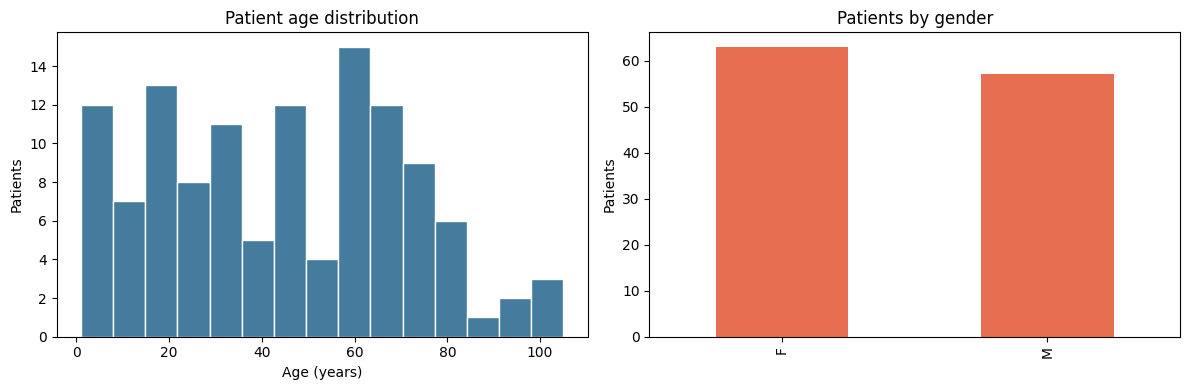

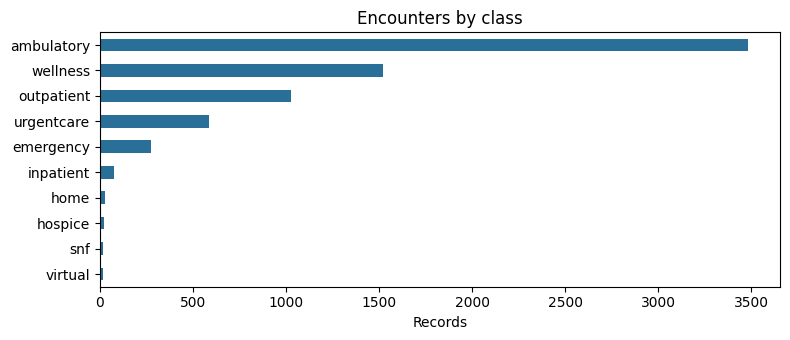

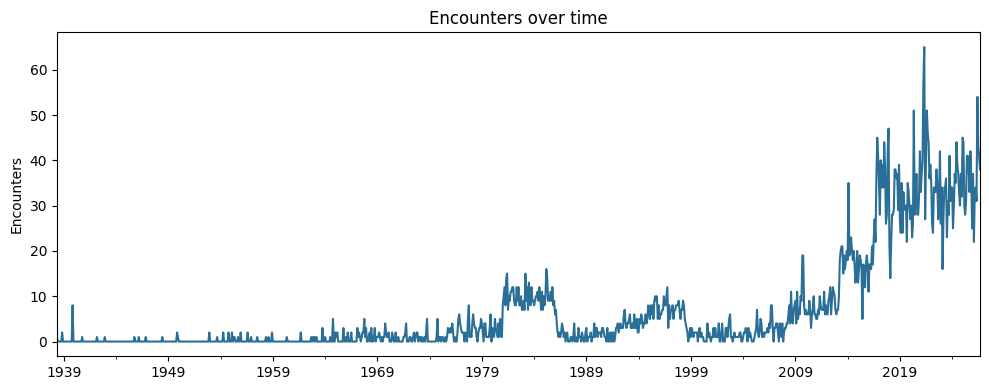

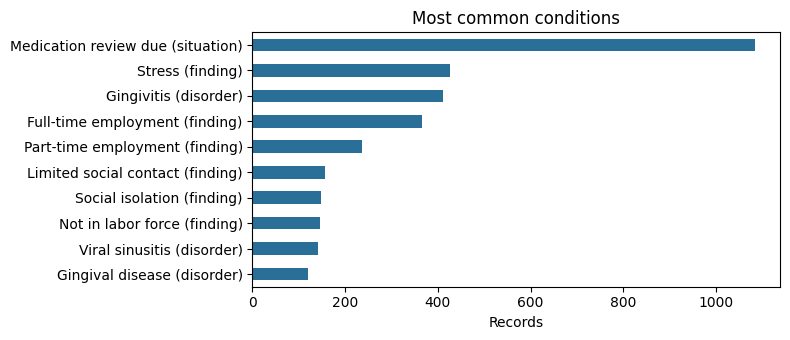

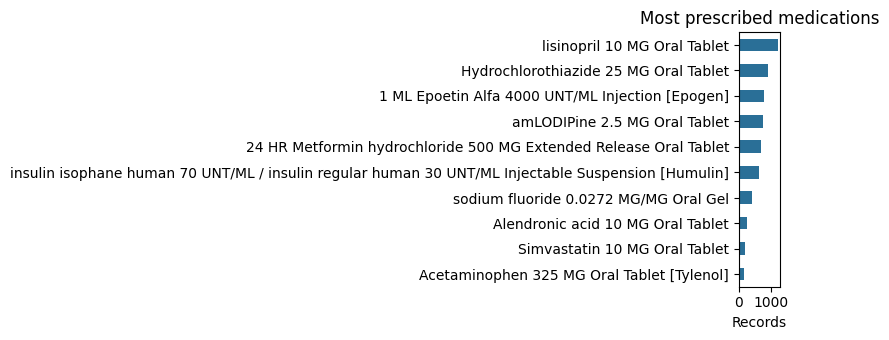

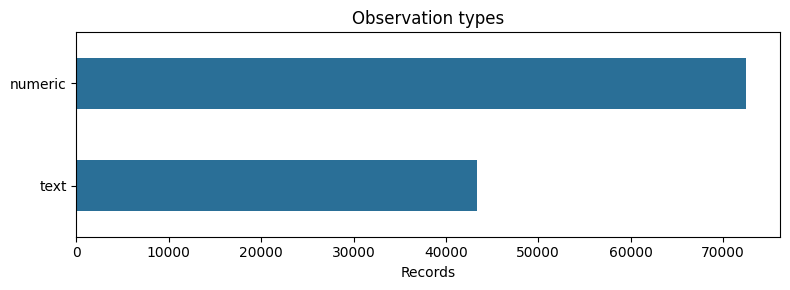

/tmp/ipykernel_615/949622650.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


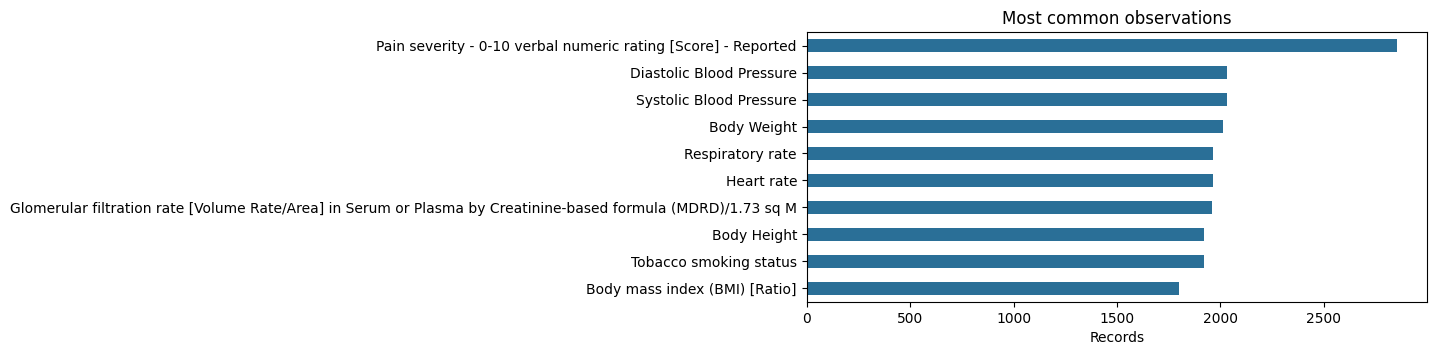

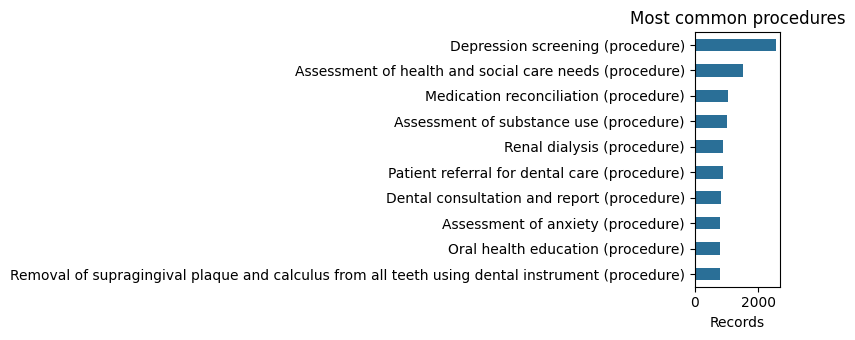

In [11]:
if not HAS_PLOTTING:
    print("Plotting is unavailable in this runtime. Google Colab includes matplotlib, so this cell will render there.")
else:
    def top_bar(series, title, n=10, color="#2a6f97"):
        values = series.value_counts().head(n).sort_values()
        ax = values.plot(kind="barh", figsize=(8, max(3, n * 0.35)), color=color)
        ax.set(title=title, xlabel="Records", ylabel="")
        plt.tight_layout()
        plt.show()

    age_end = patients["deathdate"].fillna(REFERENCE_DATE)
    age_years = ((age_end - patients["birthdate"]).dt.days / 365.25).clip(lower=0)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(age_years.dropna(), bins=15, color="#457b9d", edgecolor="white")
    axes[0].set(title="Patient age distribution", xlabel="Age (years)", ylabel="Patients")
    patients["gender"].value_counts().plot(kind="bar", ax=axes[1], color="#e76f51")
    axes[1].set(title="Patients by gender", xlabel="", ylabel="Patients")
    plt.tight_layout(); plt.show()

    top_bar(enc["encounterclass"], "Encounters by class", n=10)
    encounters_by_month = enc.set_index("start_dt").resample("ME").size()
    ax = encounters_by_month.plot(figsize=(10, 4), color="#2a6f97")
    ax.set(title="Encounters over time", xlabel="", ylabel="Encounters")
    plt.tight_layout(); plt.show()

    top_bar(con["description"], "Most common conditions")
    top_bar(med["description"], "Most prescribed medications")
    top_bar(obs["type"], "Observation types", n=2)
    top_bar(obs["description"], "Most common observations")
    top_bar(proc["description"], "Most common procedures")


## 12. Export clean CSVs

Helper columns and review flags are intentionally excluded from the database export. Dates are written consistently, code fields remain text, and no index columns are created. The audit summaries are also exported so the results remain easy to explain in the project README.


In [12]:
OUTPUT_DIR.mkdir(exist_ok=True)
helper_columns = {
    "encounters": ["start_dt", "stop_dt", "duration_hours", "is_death_certification"],
    "conditions": ["start_dt", "stop_dt"],
    "medications": ["start_dt", "stop_dt", "stop_before_start_flag", "possible_duplicate_flag"],
    "observations": ["value_parsed", "value_numeric", "date_dt", "impossible_value_flag", "range_review_flag", "flag_reason"],
    "procedures": ["start_dt", "stop_dt", "duration_minutes"],
}

export_data = {}
for table, frame in data.items():
    clean = frame.drop(columns=helper_columns.get(table, []), errors="ignore").copy()
    for date_column in ["birthdate", "deathdate"]:
        if date_column in clean and pd.api.types.is_datetime64_any_dtype(clean[date_column]):
            clean[date_column] = clean[date_column].dt.strftime("%Y-%m-%d")
    clean.to_csv(OUTPUT_DIR / f"{table}.csv", index=False)
    export_data[table] = clean

quality_summary.to_csv(OUTPUT_DIR / "data_quality_summary.csv", index=False)
cross_table.to_csv(OUTPUT_DIR / "cross_table_validation.csv", index=False)

export_check = pd.DataFrame([
    {"file": f"{table}.csv", "rows": len(frame), "columns": len(frame.columns), "index_written": False}
    for table, frame in export_data.items()
])
show(export_check, len(export_check))
print()
print(f"Saved cleaned CSVs and audit reports to: {OUTPUT_DIR.resolve()}")


,file,rows,columns,index_written
0,patients.csv,120,19,False
1,encounters.csv,7042,15,False
2,conditions.csv,5099,7,False
3,medications.csv,8001,13,False
4,observations.csv,115977,9,False
5,procedures.csv,21901,10,False



Saved cleaned CSVs and audit reports to: /content/cleaned


## Conclusion

The cleaned tables are ready for relational loading (for example, into Supabase/Postgres). Before deployment, keep the raw CSVs private, review the flagged clinical outliers if they will be shown to users, and document the final schema and import order: `patients` → `encounters` → clinical child tables.
